In [ ]:
!pip install xgboost catboost

In [ ]:
!pip install optuna

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report, f1_score

from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
import catboost as ctb

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna

from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

sns.set_theme()

In [8]:
pathTrain = 'train.csv'
pathTest = 'test.csv'

trainset = pd.read_csv(pathTrain)
testSet = pd.read_csv(pathTest)

In [9]:
trainset.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [10]:
trainset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

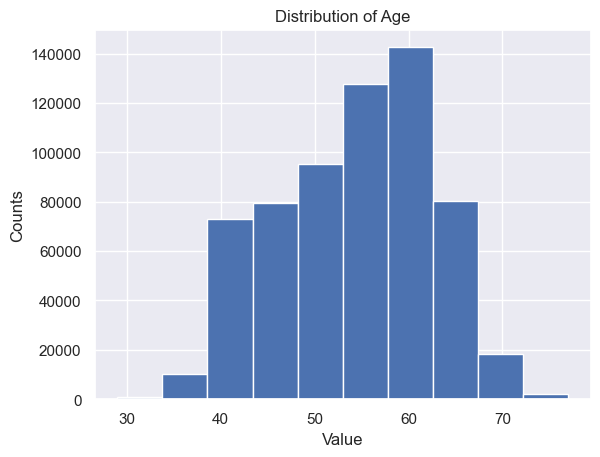

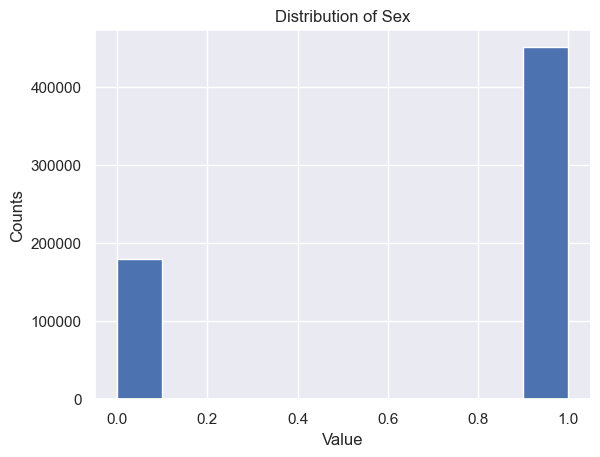

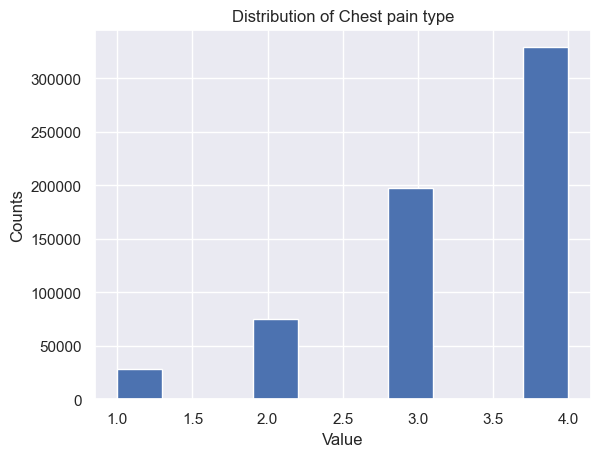

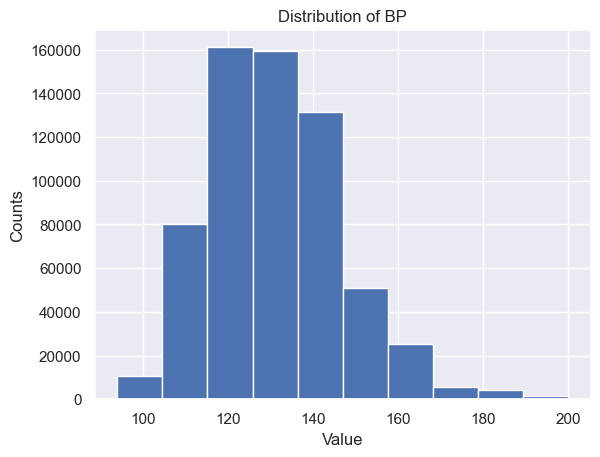

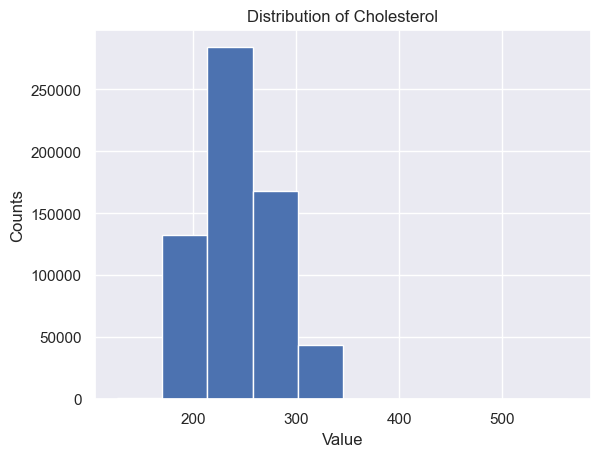

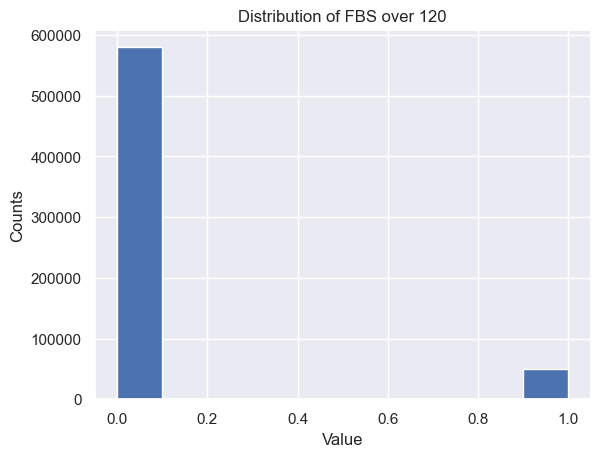

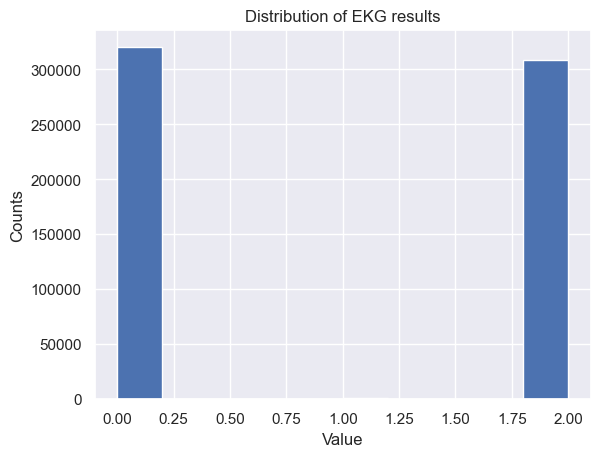

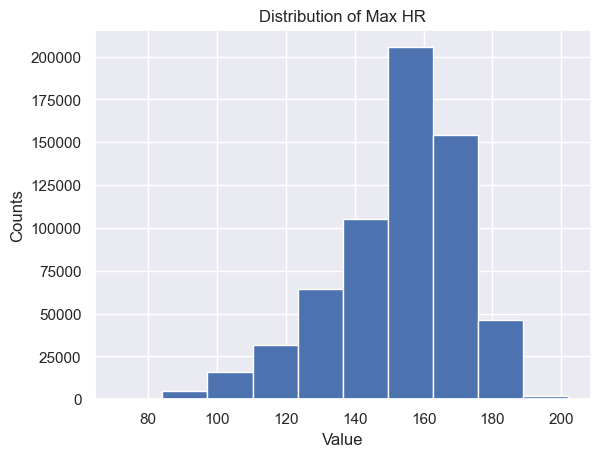

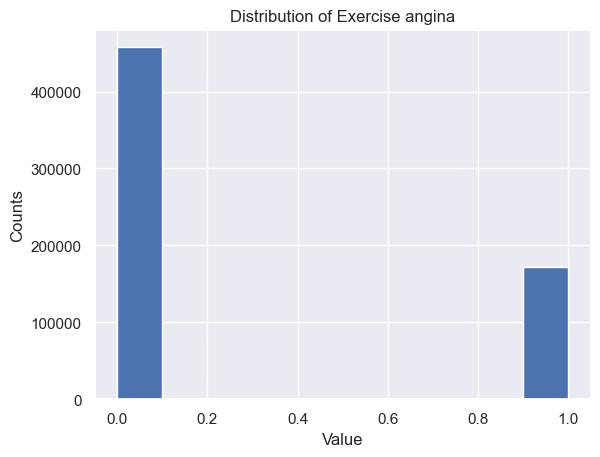

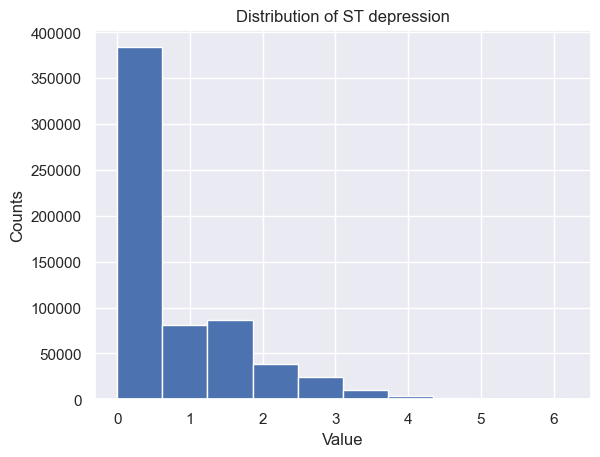

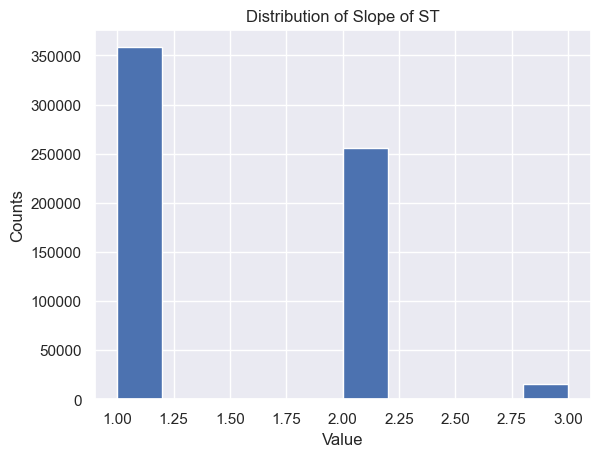

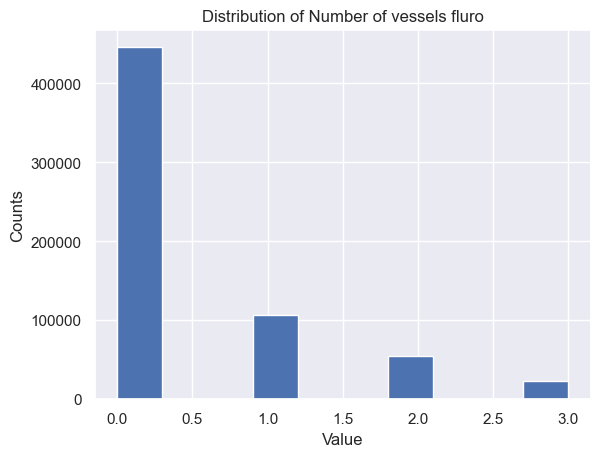

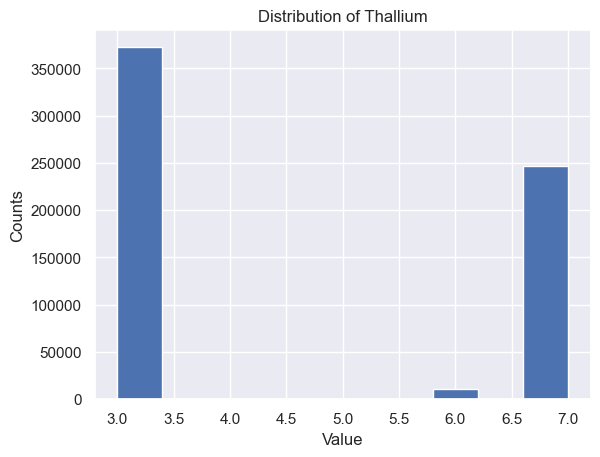

In [11]:
target = 'Heart Disease'
features = [i for i in trainset.columns[1:] if i!=target]

for i in features:
    trainset[i].hist()
    plt.title(f"Distribution of {i}")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.show()

In [12]:
trainset[target].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Not much tipping over to a side... looks good for accuracy

In [16]:
def modelEvaluation(mClass, X, y, splits = 4, verbose = False, **kwargs):
    skf = StratifiedKFold(n_splits = splits)
    f1Scores = []
    for i, (trainIdx, testIdx) in enumerate(skf.split(X, y)):
        if verbose:
            print(f"Fold {i}")
            print("Train samples:", len(trainIdx))
            print("Test samples:", len(testIdx))
        
        scaler = StandardScaler().set_output(transform = "pandas")
        X_train = scaler.fit_transform(trainset.loc[trainIdx, features])
        y_train = y[trainIdx]
        X_test = scaler.transform(trainset.loc[testIdx, features])
        y_test = y[testIdx]

        model = mClass(**kwargs)

        model.fit(X_train, y_train)

        y_prob = model.predict(X_test)

        score = f1_score(y_test, y_prob)
        report = classification_report(y_test, y_prob, target_names = label_encoder.classes_)

        f1Scores.append(score)

        if verbose:
            print("F1 Score: ", f1Scores)
            print(report)
    return np.mean(f1Scores), np.std(f1Scores)

In [17]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(trainset[target])

print('Total Classes:', len(label_encoder.classes_))
print("Classes:",  label_encoder.classes_)

exps = [
    {"mClass":LogisticRegression, "X":trainset, "y": y, "class_weight": "balanced"},
    {"mClass": GaussianNB, "X": trainset, "y": y},
    {"mClass": ctb.CatBoostClassifier, "X": trainset, "y": y, "verbose": False, "logging_level":"Silent"},
    {"mClass": lgb.LGBMClassifier, "X": trainset, "y": y, "class_weight":"balanced", "verbosity": 0}, 
    {"mClass": xgb.XGBClassifier, "X": trainset, "y": y, "class_weight":"balanced", "verbosity": 0},
]

for param in exps:
    mean, std = modelEvaluation(**param)
    print(f"Model: {param['mClass'].__name__} \nMean: {mean} | STD: {std}")

Total Classes: 2
Classes: ['Absence' 'Presence']
Model: LogisticRegression 
Mean: 0.8698156930064391 | STD: 0.00031922046671325387
Model: GaussianNB 
Mean: 0.8559808287704908 | STD: 0.00046478771664728365
Model: CatBoostClassifier 
Mean: 0.8745008936284442 | STD: 0.0006269985631267688
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Model: LGBMClassifier 
Mean: 0.8752286835444213 | STD: 0.0003561966268476274
Model: XGBClassifier 
Mean: 0.8739894614488471 | STD: 0.00047275632674916685


In [24]:
skf = StratifiedKFold(n_splits = 4, shuffle = True, random_state = 42)

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "n_jobs": -1,
        "class_weight": "balanced",
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 512),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 75, 125),
    }

    f1_scores = []

    for trainIdx, valIdx in skf.split(trainset[features], y):
        X_train_fold, X_val_fold = trainset[features].iloc[trainIdx], trainset[features].iloc[valIdx]
        y_train_fold, y_val_fold = y[trainIdx], y[valIdx]

        scaler = StandardScaler().set_output(transform = "pandas")
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train_fold,
            y_train_fold,
            eval_set = [(X_val_fold, y_val_fold)],
            eval_metric="binary_logloss",
            callbacks = [
                lgb.early_stopping(100, verbose = False),
                lgb.log_evaluation(0)
            ]
        )

        preds = model.predict(X_val_fold)
        f1 = f1_score(y_val_fold, preds)
        f1_scores.append(f1)

        trial.report(np.mean(f1_scores), step = len(f1_scores))

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
    return np.mean(f1_scores) 


In [25]:
study = optuna.create_study(
    direction = "maximize",
    sampler = optuna.samplers.TPESampler(seed = 42),
    pruner = optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials = 100)

print("Best F1: ", study.best_value)
print("Best Parameters: ", study.best_params)

[I 2026-02-13 10:24:35,663] A new study created in memory with name: no-name-dc740f13-bc11-4f98-8b7c-9a9fcd2d6ae9
[I 2026-02-13 10:24:54,079] Trial 0 finished with value: 0.8737673150482486 and parameters: {'learning_rate': 0.005611516415334507, 'num_leaves': 488, 'max_depth': 12, 'min_child_samples': 62, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'n_estimators': 105}. Best is trial 0 with value: 0.8737673150482486.
[I 2026-02-13 10:25:01,334] Trial 1 finished with value: 0.8725013807478139 and parameters: {'learning_rate': 0.02607024758370768, 'num_leaves': 26, 'max_depth': 15, 'min_child_samples': 84, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'n_estimators': 101}. Best is trial 0 with value: 0.8737673150482486.
[I 2026-02-13 10:25:11,135] Trial 2 finished with value: 0.872792196775

Best F1:  0.8757138592746251
Best Parameters:  {'learning_rate': 0.08727208668696819, 'num_leaves': 90, 'max_depth': 10, 'min_child_samples': 32, 'subsample': 0.7471647051139232, 'colsample_bytree': 0.5749128974755893, 'reg_alpha': 1.4776148321798919e-06, 'reg_lambda': 7.841158429491672, 'n_estimators': 107}


In [26]:
X_train, X_test, y_train, y_test = train_test_split(trainset[features], y, test_size=0.1, random_state=42, stratify=y)

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = lgb.LGBMClassifier(class_weight="balanced", verbosity=0, **study.best_params)
model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines


,boosting_type,'gbdt'
,num_leaves,90
,max_depth,10
,learning_rate,0.08727208668696819
,n_estimators,107
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,32


In [27]:
f1_score(y_test, model.predict(X_test))

0.8784561403508772

In [28]:
# Permutation Importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
})
print("\nPermutation Importance:")
print(perm_importance_df.sort_values(by='Importance Mean', ascending=False))


Permutation Importance:
                    Feature  Importance Mean  Importance Std
12                 Thallium         0.046576        0.000922
7                    Max HR         0.038075        0.000953
2           Chest pain type         0.031972        0.000856
11  Number of vessels fluro         0.018958        0.000547
8           Exercise angina         0.012179        0.000541
10              Slope of ST         0.009208        0.000559
9             ST depression         0.009162        0.000527
1                       Sex         0.008433        0.000532
0                       Age         0.005516        0.000526
6               EKG results         0.002251        0.000360
4               Cholesterol         0.001386        0.000355
3                        BP         0.000617        0.000173
5              FBS over 120         0.000031        0.000049


In [29]:
print(label_encoder.classes_)

['Absence' 'Presence']


In [30]:

X_test = testSet[features]
X_test = scaler.transform(X_test)
y_prob = model.predict_proba(X_test)
submission = pd.DataFrame({
    "id": testSet["id"], 
    "Heart Disease": y_prob[:, 1]
})
submission.to_csv("submission.csv", index=False)

In [31]:
submission.head()

,id,Heart Disease
0,630000,0.937417
1,630001,0.010973
2,630002,0.984958
3,630003,0.007116
4,630004,0.224470
